In [16]:
import math
import sys
from pathlib import Path

ROOT = Path("/Users/ivanr/Developer/ai-vineyard-productivity")
sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rich import print

from src.dataset.pipeline import make_pipeline_from_config
from src.visual.visualizer import plot_snapshot
from src.visual.panels import _make_s2_rgb, SARRGBComposite


IMAGES = ROOT / "images/dataset"
BASE = str(ROOT / "agrixel-fair-dockerV2/data/output/files")
CONFIG = str(ROOT / "src/config/dataset.yml")
PARCEL = "L1112,L1119"
MASK  = "MULTIPOLYGON (((197985.27670359833 5068113.845292556, 197898.61033927836 5068180.770629686, 197884.15663008371 5068192.583920743, 197872.950001874 5068202.818006252, 197870.65465152258 5068202.150008699, 197866.40246834306 5068205.28507133, 197866.14904673517 5068205.435408128, 197886.71295990396 5068256.040847472, 197890.19330820107 5068271.622250592, 197898.32062127668 5068266.946608396, 197943.34261212306 5068244.712686803, 197983.00869217588 5068225.637263162, 198021.527003746 5068207.233356839, 198023.61717216967 5068205.8779628705, 198029.30898789276 5068214.8685806235, 198029.23294274902 5068214.352908743, 198029.37215668088 5068214.388223623, 198029.49550843553 5068214.314485159, 198029.10931107358 5068211.622969383, 198028.5142928138 5068207.778871878, 198025.38645807878 5068187.570836843, 198022.0227434378 5068168.293834397, 198020.25961578568 5068157.818924508, 198019.35211263457 5068152.426972216, 198019.1238838964 5068151.070964208, 198019.04905174262 5068150.626049381, 198018.69840431906 5068148.8600684805, 198015.11476525615 5068130.81069781, 198012.45775726394 5068128.916767401, 198012.0472067946 5068126.92709014, 198008.52020503508 5068116.021611821, 198005.8422029848 5068109.281763295, 197998.9932880866 5068105.265113251, 197985.27670359833 5068113.845292556)), ((198018.7370333859 5068216.447802607, 198018.83034031076 5068216.820847209, 198010.04987876117 5068222.056032314, 197959.66245981483 5068247.150043278, 197909.45241733265 5068272.65447094, 197891.0610626022 5068281.13519552, 197891.3839045622 5068281.513340934, 197891.4796374671 5068281.615307144, 197894.25682477848 5068284.573571207, 197894.35824940578 5068284.778995884, 197900.12041855018 5068296.455630128, 197905.95396749215 5068312.386520413, 197913.27781463787 5068324.517188412, 197913.66223916825 5068325.197878095, 197941.1401954688 5068312.410271156, 198000.46660443008 5068285.251895441, 198037.6015475323 5068265.936647098, 198036.57386506198 5068254.541948261, 198033.5027609373 5068240.536689941, 198032.97035162407 5068238.108785617, 198032.82824517754 5068237.488908479, 198032.78280470512 5068237.290572673, 198032.6734489892 5068236.515011318, 198032.4254391829 5068235.5234567765, 198021.43369682116 5068215.204320707, 198018.7370333859 5068216.447802607)))"
MASK  = "POLYGON ((197891.3839045622 5068281.513340934, 197885.44193297357 5068283.767789229, 197874.68233824088 5068289.695635355, 197870.88250703306 5068291.653388444, 197869.558948304 5068292.3353193, 197868.2021723097 5068293.034410394, 197868.36135392348 5068293.148935994, 197868.33457483607 5068293.232622997, 197862.9187609967 5068297.201476831, 197852.8039171147 5068301.665739884, 197845.20854681768 5068305.918611101, 197838.7700890819 5068307.472978114, 197834.1326416097 5068310.370318894, 197825.38950283002 5068315.978603194, 197811.76622526653 5068323.365089524, 197784.56641690902 5068334.892550792, 197780.72198499113 5068337.3546756515, 197769.79537086296 5068343.821113838, 197760.30801605058 5068346.912700043, 197751.3778901935 5068347.927643811, 197751.89481055722 5068350.829597687, 197752.08888896092 5068351.259848454, 197754.52429300654 5068356.9999675285, 197757.18633957265 5068361.959171527, 197759.12908305507 5068365.578008037, 197763.89258818276 5068372.816182532, 197765.30702785662 5068374.965451855, 197770.63214736505 5068382.578425308, 197775.1474560726 5068380.463226274, 197776.8573054706 5068380.711305148, 197780.6624551731 5068381.263420561, 197783.21216020166 5068381.633487129, 197786.82117874813 5068389.551621787, 197798.33226745366 5068385.6560966885, 197826.00299586094 5068373.645225438, 197846.06286502164 5068364.327170262, 197865.99639660612 5068354.932773195, 197884.58238958183 5068345.187345621, 197898.26099815173 5068337.060091083, 197912.70985538626 5068330.438717741, 197915.72805448459 5068328.855995308, 197913.66223916825 5068325.197878095, 197913.27781463787 5068324.517188412, 197905.95396749215 5068312.386520413, 197900.12041855018 5068296.455630128, 197894.35824940578 5068284.778995884, 197894.25682477848 5068284.573571207, 197891.4796374671 5068281.615307144, 197891.3839045622 5068281.513340934))"

pipeline = make_pipeline_from_config(BASE, CONFIG)

In [17]:
# Helper Functions

RESAMPLE_PERIOD = "ME"
ROLLING_WINDOW = 4
def smooth(da, resample_period: str = RESAMPLE_PERIOD, window: int = ROLLING_WINDOW):
    return da.resample(time=resample_period).median().rolling(time=window, min_periods=1).mean()

def plot_bands(bands, time=0, cols=3):
    n = len(bands)
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
    axes = np.array(axes).flatten()

    for i, band in enumerate(bands):
        band.isel(time=time).plot(ax=axes[i])
        axes[i].set_title(band.name)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

# Sentinel 1

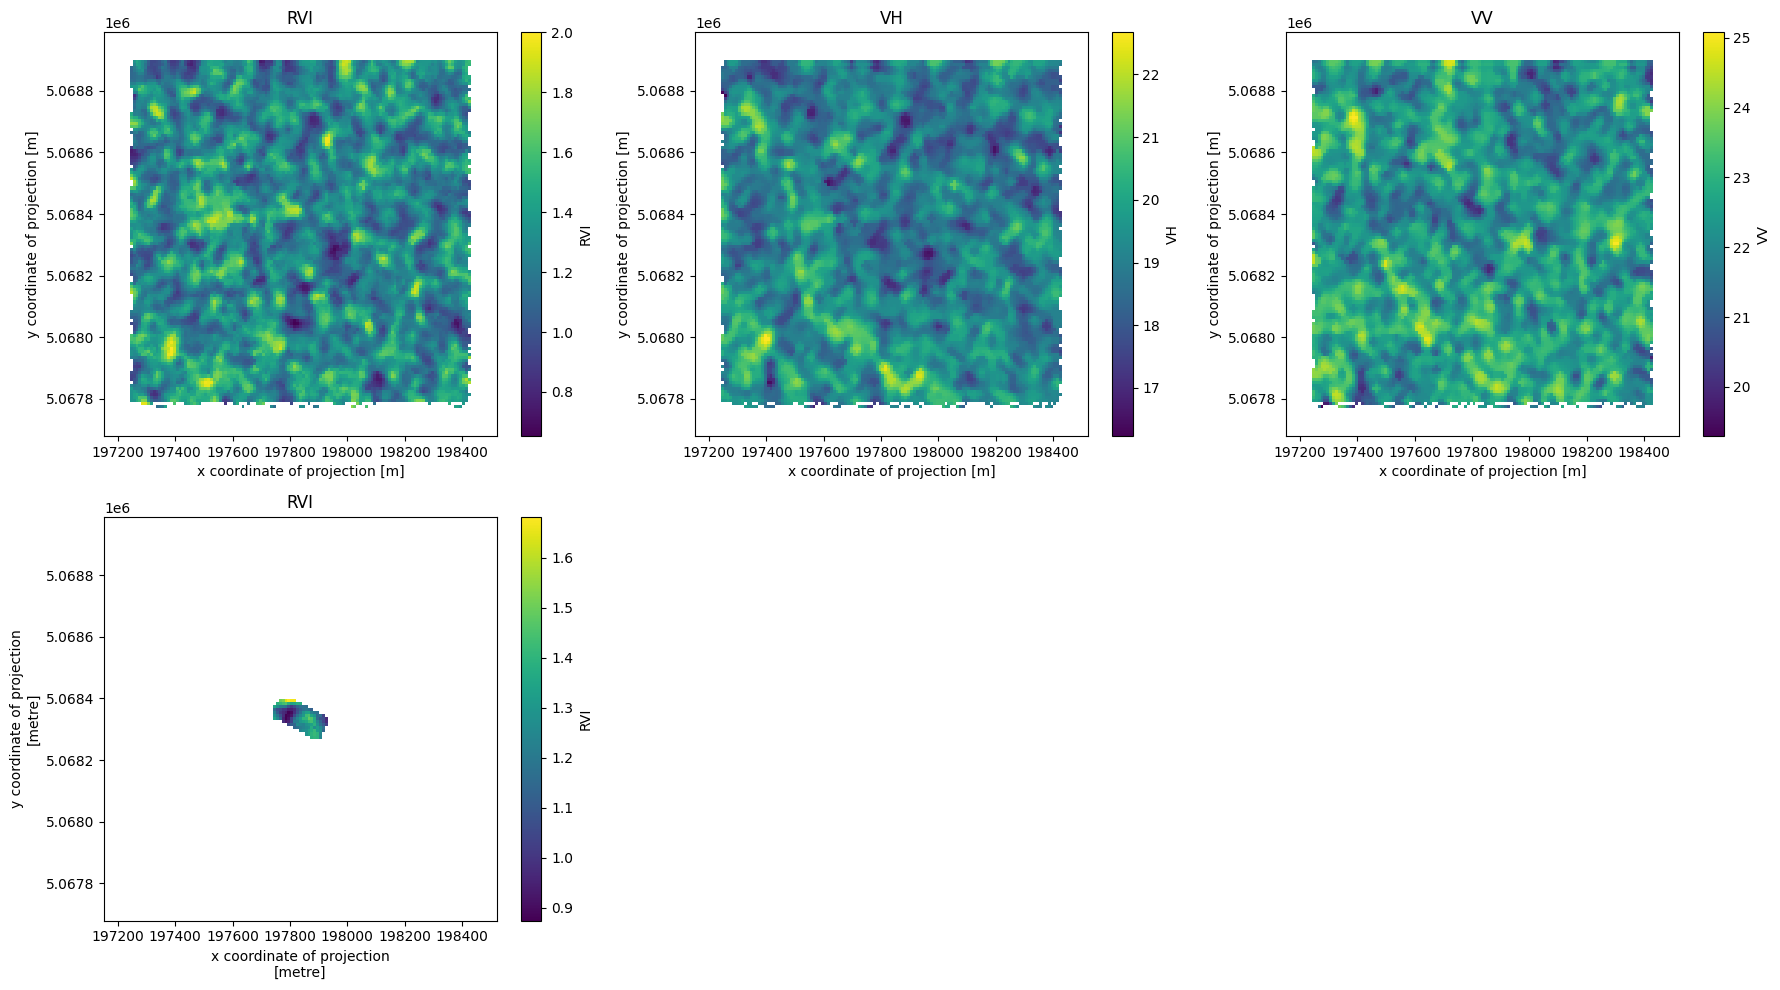

In [18]:
s1 = pipeline.load_with_indices(PARCEL, "SENTINEL-1")
s1_parcel = s1.mask(MASK)

plot_bands([s1.ds.RVI, s1.ds.VH, s1.ds.VV, s1_parcel.ds.RVI], time=12)


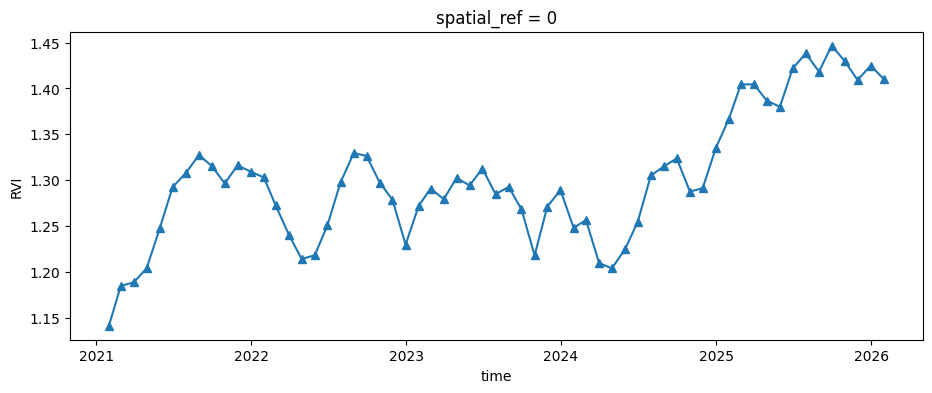

In [19]:
s1_rvi_timeseries = smooth(s1_parcel.ds.RVI.mean(["x", "y"]))
s1_rvi_timeseries.plot.line("-^", figsize=(11, 4))

# Sentinel 2

In [20]:
s2 = pipeline.load_with_indices(PARCEL, "SENTINEL-2")
s2_parcel = s2.mask(MASK)
time = 0

**Bands**

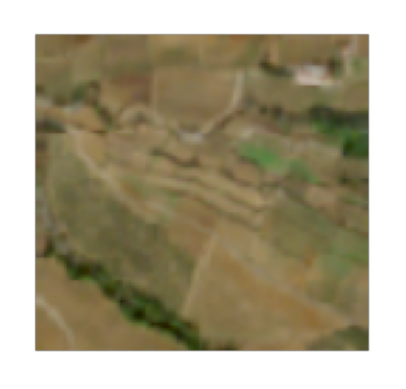

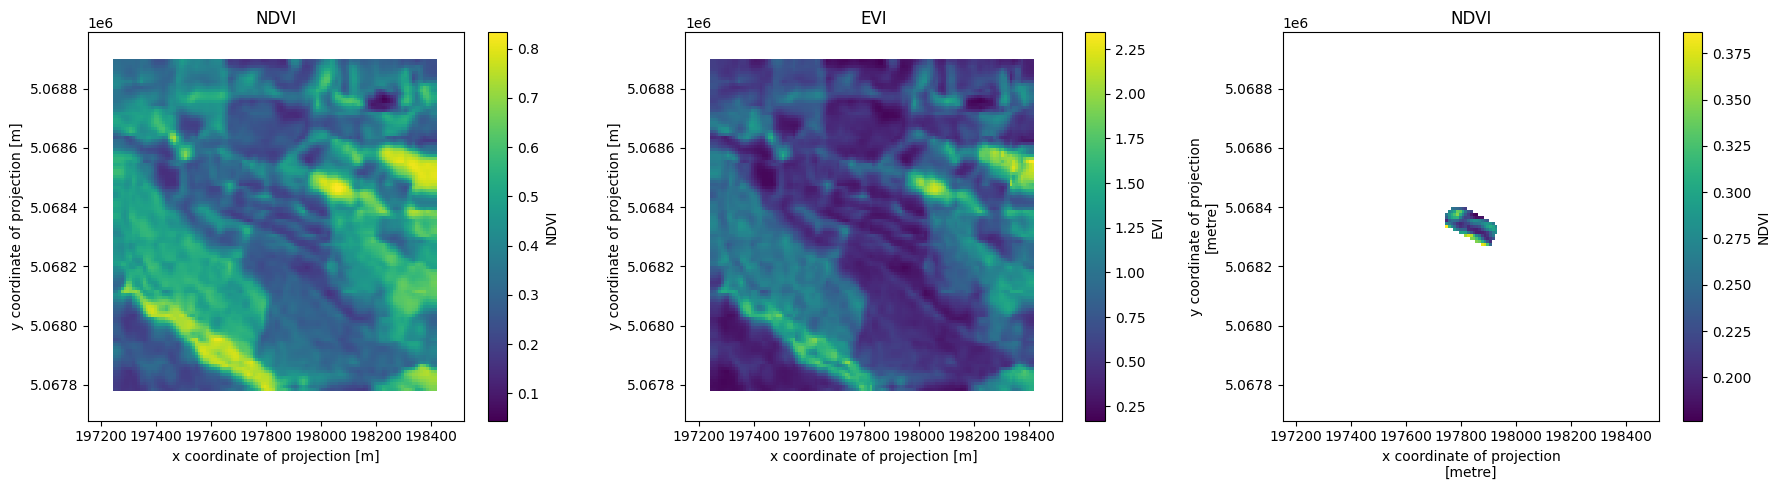

In [21]:
# Visual Bands
rgb  = _make_s2_rgb(
    s2.ds["B04"].isel(time=time).values,
    s2.ds["B03"].isel(time=time).values,
    s2.ds["B02"].isel(time=time).values,
)
plt.imshow(rgb)
plt.axis("off")  # hides both x and y axes
plt.show()

plot_bands([s2.ds.NDVI, s2.ds.EVI, s2_parcel.ds.NDVI], time=time)

**Time Series**

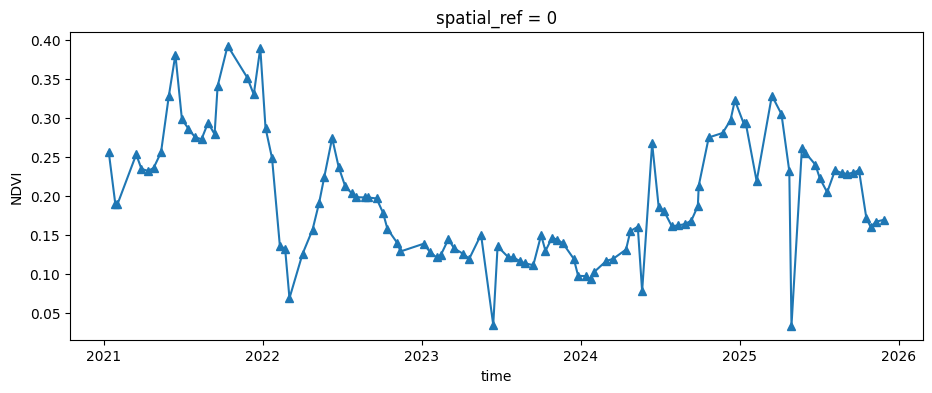

In [22]:
# Timeseries for parcel
# parcel_ndvi_timesrires = smooth(s2_parcel.ds.NDVI.mean(["x", "y"]))
parcel_ndvi_timesrires = s2_parcel.ds.NDVI.mean(["x", "y"])
parcel_ndvi_timesrires.plot.line("-^", figsize=(11, 4))

# Sentinel 3

In [23]:
s3 = pipeline.load_with_indices(PARCEL, "SENTINEL-3")
parcel_s3 = s3.mask(MASK)

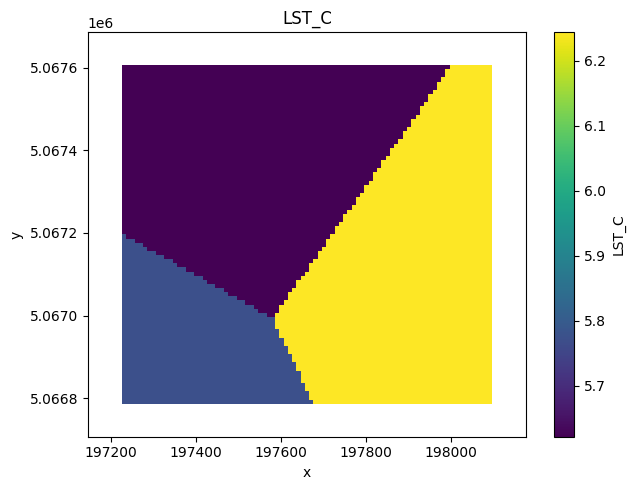

In [24]:
plot_bands([s3.ds.LST_C], time=1)


In [25]:
df = pd.DataFrame({
    "time":  s3.ds["time"].values,
    "min":   s3.ds["LST"].min(dim=["x", "y"]).values,
    "max":   s3.ds["LST"].max(dim=["x", "y"]).values,
    "mean":  s3.ds["LST"].mean(dim=["x", "y"]).values,
})

df["time"] = pd.to_datetime(df["time"])
df = df.set_index("time")

print(df.round(2))

min         max        mean
time                                                   
2021-01-15 21:38:29  273.109985  273.709991  273.359985
2021-01-30 21:49:39  278.769989  279.390015  279.049988
2021-02-14 22:00:53  264.839996  265.859985  265.350006
2021-03-01 21:10:35  278.040009  279.269989  278.320007
2021-03-16 21:21:46  280.220001  280.630005  280.619995
...                         ...         ...         ...
2025-10-04 21:06:59  290.899994  292.059998  291.440002
2025-10-21 22:06:50  284.480011  287.420013  285.760010
2025-11-05 21:39:24  240.869995  241.410004  241.139999
2025-11-18 21:40:38  276.399994  277.130005  276.720001
2026-01-01 09:42:34  273.730011  273.920013  273.799988

[120 rows x 3 columns]

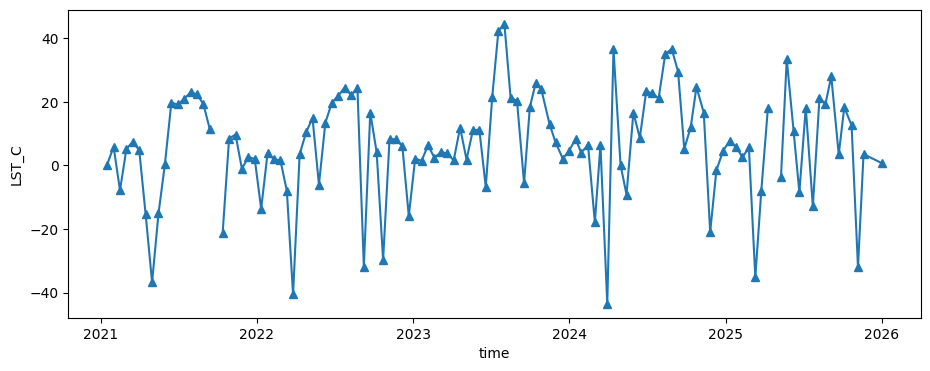

In [26]:
s3_series = s3.ds.LST_C.mean(["x", "y"])
s3_series.plot.line("-^", figsize=(11, 4))

# MODIS

In [27]:
modis = pipeline.load(PARCEL, "MODIS")
parcel_modis = modis.mask(MASK)
modis.ds.info()

FileNotFoundError: Zarr store not found: /Users/ivanr/Developer/ai-vineyard-productivity/agrixel-fair-dockerV2/data/output/files/MODIS/L1112,L1119/cube.zarr

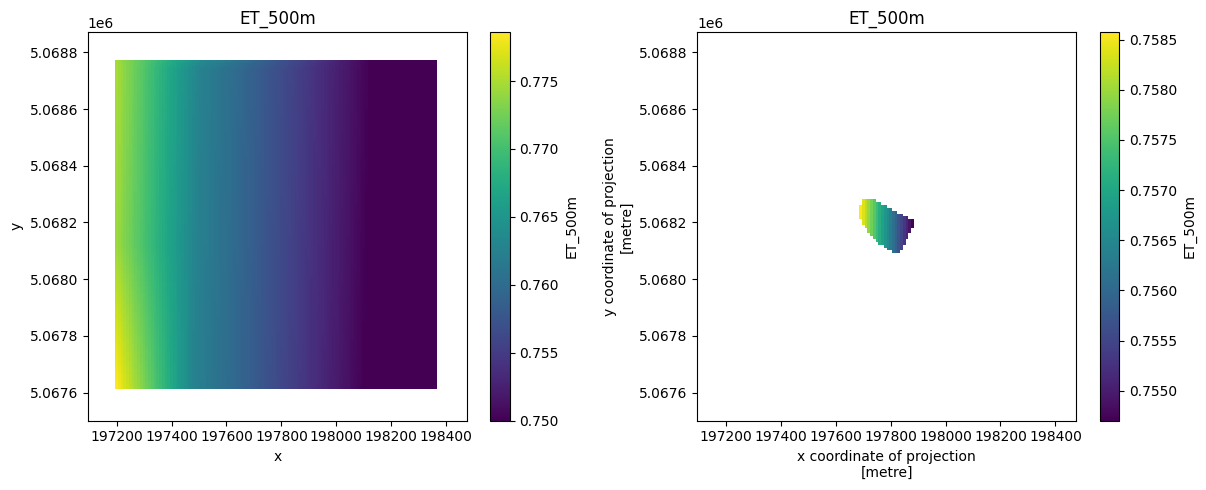

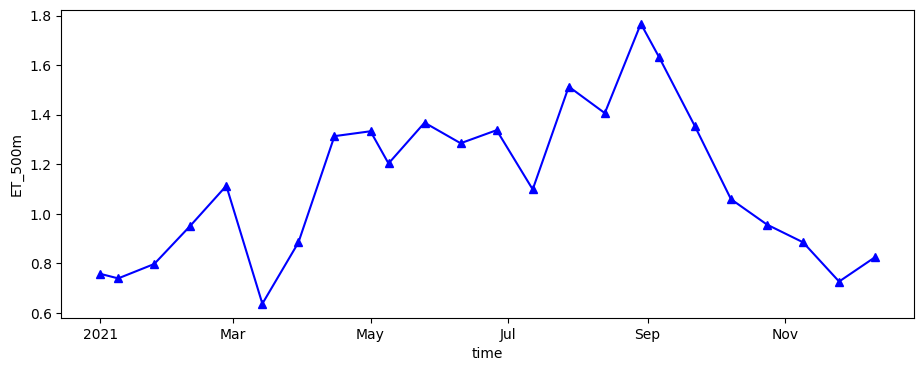

In [ ]:
plot_bands([modis.ds.ET_500m, parcel_modis.ds.ET_500m], time=time)
modis.ds.ET_500m.mean(["x", "y"]).plot.line("b-^", figsize=(11, 4))

# ERA 5

In [ ]:
era5 = pipeline.load(PARCEL, "ERA5")
era5.ds.info

<bound method Dataset.info of <xarray.Dataset> Size: 61MB
Dimensions:    (x: 103, y: 102, time: 730)
Coordinates:
  * x          (x) float64 824B 1.973e+05 1.973e+05 ... 1.983e+05 1.983e+05
    longitude  (x) float32 412B 1.772 1.772 1.772 1.772 ... 1.781 1.781 1.781
  * y          (y) float64 816B 5.069e+06 5.069e+06 ... 5.068e+06 5.068e+06
    latitude   (y) float32 408B 41.38 41.38 41.38 41.38 ... 41.37 41.37 41.37
  * time       (time) datetime64[ns] 6kB 2021-01-01 2021-01-02 ... 2022-12-31
    number     int64 8B 0
Data variables:
    tp         (time, y, x) float32 31MB 0.00347 0.00347 ... 6.771e-07 6.771e-07
    TP_MM      (time, y, x) float32 31MB 3.47 3.47 3.469 ... 0.0006771 0.0006771
Attributes:
    crs:        EPSG:3857
    res_m:      10.0
    height:     102
    width:      103
    variables:  ['tp']
    time_iso:   ['2021-01-01T00:00:00Z', '2021-01-02T00:00:00Z', '2021-01-03T...
    transform:  [10.0, 0.0, 197266.89885392122, 0.0, -10.0, 5068700.452230195]>

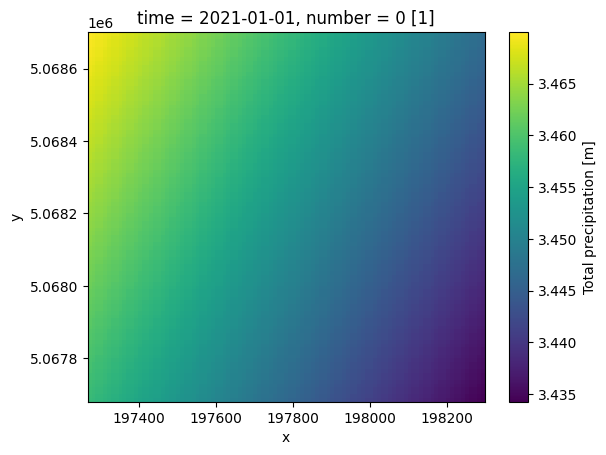

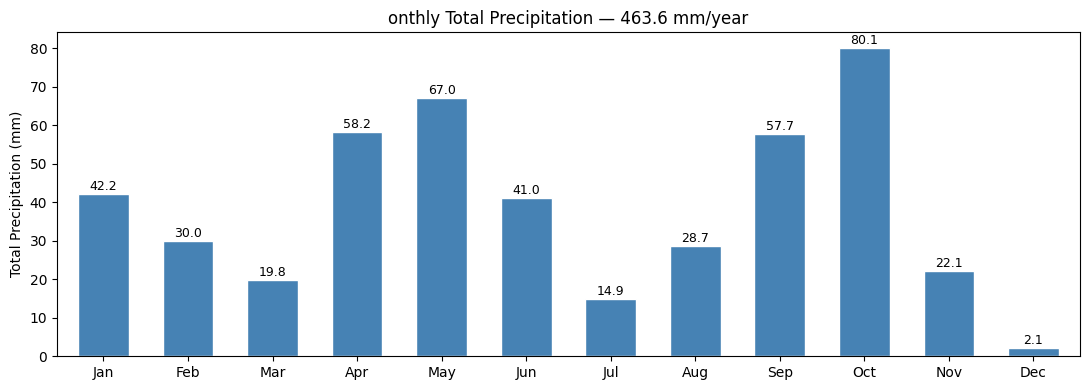

In [ ]:
era5.ds.TP_MM.isel(time=time).plot()

tp = era5.ds.TP_MM.mean(["x", "y"]).to_pandas()
tp_2021 = tp[tp.index.year == 2021]                                                     
monthly = tp_2021.groupby(tp_2021.index.month).sum() 

fig, ax = plt.subplots(figsize=(11, 4))
monthly.plot.bar(ax=ax, color="steelblue", edgecolor="white", width=0.6)
ax.set_xticklabels([pd.Timestamp(2000, m, 1).strftime("%b") for m in monthly.index], rotation=0)
ax.set_ylabel("Total Precipitation (mm)")
ax.set_xlabel("")
ax.set_title(f"onthly Total Precipitation — {monthly.sum():.1f} mm/year")

for bar, val in zip(ax.patches, monthly):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3, f"{val:.1f}", 
            ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()